<a href="https://colab.research.google.com/github/scottspurlock/csc4422-s2026/blob/main/labs/day10_lab_spurlock.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DMML Day 10 Lab: Decision Trees

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

file_link = 'https://drive.google.com/uc?export=download&id=1mBUfbCgCt15r8XnK7PEK_2U5MPwdnIeE'
df = pd.read_csv(file_link)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,No,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,Yes,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,Yes,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,Yes,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,No,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [2]:
df = df.drop(['PassengerId', 'Name', 'Ticket'], axis=1)
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,No,3,male,22.0,1,0,7.2500,NaN,S
1,Yes,1,female,38.0,1,0,71.2833,C85,C
2,Yes,3,female,26.0,0,0,7.9250,NaN,S
3,Yes,1,female,35.0,1,0,53.1000,C123,S
4,No,3,male,35.0,0,0,8.0500,NaN,S


Make a new column, Deck, that is the first letter of the Cabin column. For passengers that didn’t have a cabin, set Deck to X.

In [3]:
df['Cabin'] = df['Cabin'].fillna('X')
df['Deck'] = df['Cabin'].str[0]
df = df.drop(['Cabin'], axis=1)
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Deck
0,No,3,male,22.0,1,0,7.2500,S,X
1,Yes,1,female,38.0,1,0,71.2833,C,C
2,Yes,3,female,26.0,0,0,7.9250,S,X
3,Yes,1,female,35.0,1,0,53.1000,S,C
4,No,3,male,35.0,0,0,8.0500,S,X


In [4]:
# Just a subset of the columns
df = pd.get_dummies(df, columns=['Embarked'], dtype=float)
df = pd.get_dummies(df, columns=['Sex'], drop_first=True, dtype=float)
df.head()


,Survived,Pclass,Age,SibSp,Parch,Fare,Deck,Embarked_C,Embarked_Q,Embarked_S,Sex_male
0,No,3,22.0,1,0,7.2500,X,0.0,0.0,1.0,1.0
1,Yes,1,38.0,1,0,71.2833,C,1.0,0.0,0.0,0.0
2,Yes,3,26.0,0,0,7.9250,X,0.0,0.0,1.0,0.0
3,Yes,1,35.0,1,0,53.1000,C,0.0,0.0,1.0,0.0
4,No,3,35.0,0,0,8.0500,X,0.0,0.0,1.0,1.0


In [5]:
df['Deck'].value_counts().sort_index()

,count
Deck,
A,15
B,47
C,59
D,33
E,32
F,13
G,4
T,1
X,687


In [6]:
ord_map = {
    'A': 1,
    'B': 2,
    'C': 3,
    'D': 4,
    'E': 5,
    'F': 6,
    'G': 7,
    'T': 8,
    'X': 9
}
df['Deck'] = df['Deck'].map(ord_map)
df.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Deck,Embarked_C,Embarked_Q,Embarked_S,Sex_male
0,No,3,22.0,1,0,7.2500,9,0.0,0.0,1.0,1.0
1,Yes,1,38.0,1,0,71.2833,3,1.0,0.0,0.0,0.0
2,Yes,3,26.0,0,0,7.9250,9,0.0,0.0,1.0,0.0
3,Yes,1,35.0,1,0,53.1000,3,0.0,0.0,1.0,0.0
4,No,3,35.0,0,0,8.0500,9,0.0,0.0,1.0,1.0


## Separate X and y

In [7]:
y = df['Survived']
X = df.drop(['Survived'], axis=1)
X.head()

,Pclass,Age,SibSp,Parch,Fare,Deck,Embarked_C,Embarked_Q,Embarked_S,Sex_male
0,3,22.0,1,0,7.2500,9,0.0,0.0,1.0,1.0
1,1,38.0,1,0,71.2833,3,1.0,0.0,0.0,0.0
2,3,26.0,0,0,7.9250,9,0.0,0.0,1.0,0.0
3,1,35.0,1,0,53.1000,3,0.0,0.0,1.0,0.0
4,3,35.0,0,0,8.0500,9,0.0,0.0,1.0,1.0


Divide the data into randomized training and test partitions. Use 10% of the data
as the test set, keeping 90% for training.


In [8]:
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.10, random_state=13)

Xtrain.head()

,Pclass,Age,SibSp,Parch,Fare,Deck,Embarked_C,Embarked_Q,Embarked_S,Sex_male
299,1,50.0,0,1,247.5208,2,1.0,0.0,0.0,0.0
647,1,56.0,0,0,35.5000,1,1.0,0.0,0.0,1.0
476,2,34.0,1,0,21.0000,9,0.0,0.0,1.0,1.0
390,1,36.0,1,2,120.0000,2,0.0,0.0,1.0,1.0
473,2,23.0,0,0,13.7917,4,1.0,0.0,0.0,0.0


Make a decision tree classifier and fit it to the training data.

In [9]:
from sklearn import tree

model = tree.DecisionTreeClassifier()
model.fit(Xtrain, ytrain)

DecisionTreeClassifier()

Visualize your tree. To make the visualization more manageable, in the plot_tree function, add the parameter max_depth=3 to keep your tree height shorter.

In [10]:
print(model.classes_)
print(ytrain.unique())
print(model.feature_names_in_)
print(X.columns)

['No' 'Yes']
['Yes' 'No']
['Pclass' 'Age' 'SibSp' 'Parch' 'Fare' 'Deck' 'Embarked_C' 'Embarked_Q'
 'Embarked_S' 'Sex_male']
Index(['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Deck', 'Embarked_C',
       'Embarked_Q', 'Embarked_S', 'Sex_male'],
      dtype='object')


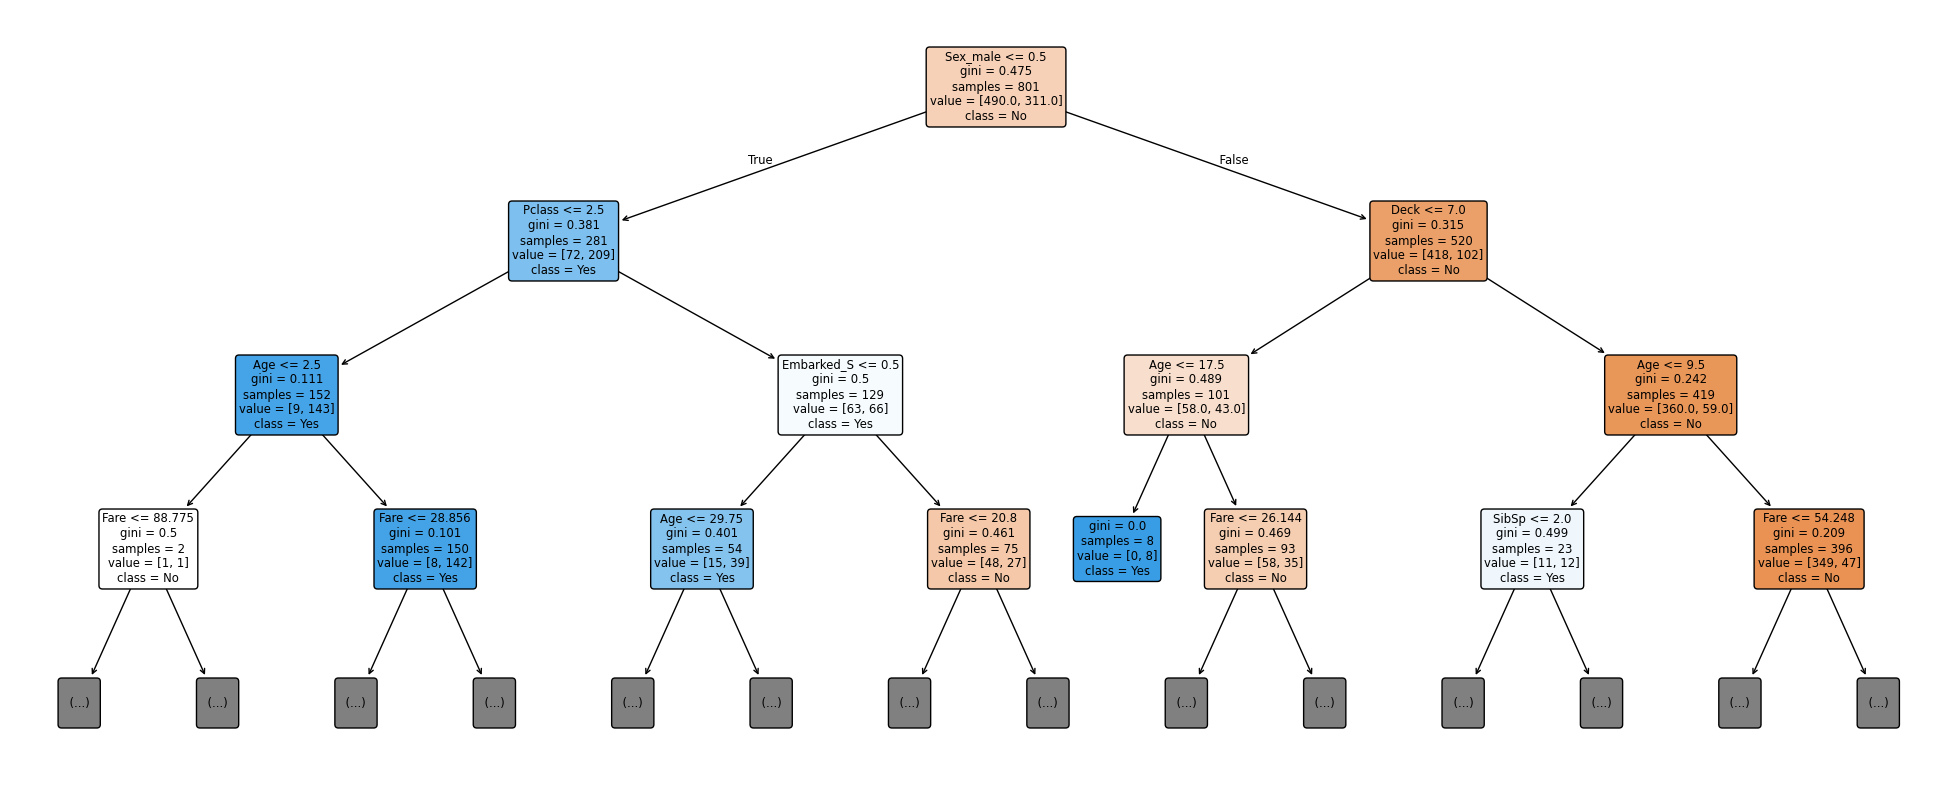

In [11]:
fig, ax = plt.subplots(figsize=(25, 10))

# tree.plot_tree(model, feature_names=X.columns,
#                class_names=ytrain.unique(),
#                max_depth=3,
#                rounded=True, filled=True, ax=ax);fig, ax = plt.subplots(figsize=(25, 10))

# Note that we should use model.classes_ to get the class names
tree.plot_tree(model, feature_names=model.feature_names_in_,
               class_names=model.classes_,
               max_depth=3,
               rounded=True, filled=True, ax=ax);

## In a text cell, note 3 observations about the tree. One observation should relate to: what is the top (root) node and what does this mean?


Use your trained model to predict the labels for the test set.

In [12]:
ypred = model.predict(Xtest)


Show a confusion matrix.

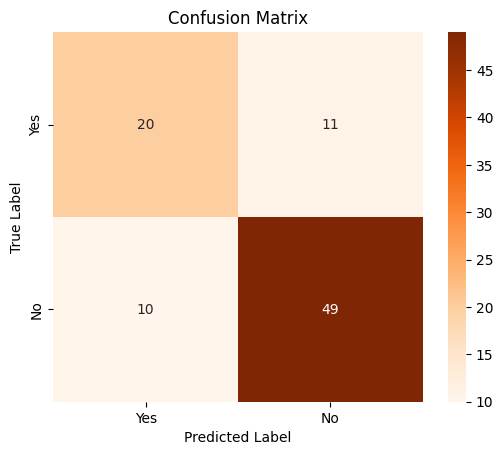

In [13]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Note that is doesn't matter what order the classes are in, as long as
# we're consistent between the call to confusion_matrix and heatmap
classes = ytrain.unique()
cm = confusion_matrix(ytest, ypred, labels=classes)
sns.heatmap(cm, square=True, annot=True, fmt='d', cbar=True,
                    cmap="Oranges",
                    xticklabels=classes,
                    yticklabels=classes)

plt.xlabel('Predicted Label');
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

## Classification report

In [14]:
from sklearn.metrics import classification_report

print(classification_report(ytest, ypred))

              precision    recall  f1-score   support

          No       0.82      0.83      0.82        59
         Yes       0.67      0.65      0.66        31

    accuracy                           0.77        90
   macro avg       0.74      0.74      0.74        90
weighted avg       0.76      0.77      0.77        90



## Questions
1. What is the precision for class label No (i.e., didn’t survive)? What does this mean in English?
2. What is the math to calculate this precision value? (I.e., which values from the confusion matrix get added and divided to get the precision?)
3. What is the recall for class label Yes (i.e., survived)? What does this mean in English?
4. What is the math to calculate this recall value? (I.e., which values from the confusion matrix get added and divided to get the recall?)
5. What is the overall accuracy?
6. What is the math to calculate this accuracy value? (I.e., which values from the confusion matrix get added and divided to get the accuracy?)



## Challenge

In [15]:
depth_vals = np.arange(1, 21)
acc_vals_train = []
acc_vals_test = []

for d in depth_vals:
    model = tree.DecisionTreeClassifier(max_depth=d)
    model.fit(Xtrain, ytrain)

    # predict training data
    ypred = model.predict(Xtrain)
    acc_vals_train.append(accuracy_score(ytrain, ypred))

    # predict testing data
    ypred = model.predict(Xtest)
    acc_vals_test.append(accuracy_score(ytest, ypred))


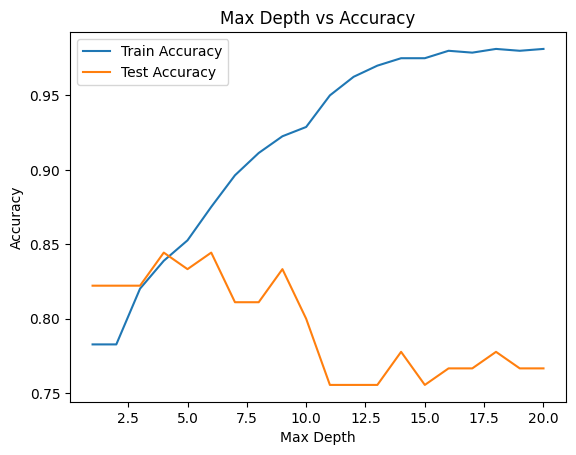

In [16]:
plt.plot(depth_vals, acc_vals_train, label='Train Accuracy')
plt.plot(depth_vals, acc_vals_test, label='Test Accuracy')
plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.title('Max Depth vs Accuracy')
plt.legend();